# ⚽ Real-World Data Challenge
## FIFA 19 — What Makes a Top Football Player?
### ⏱️ Time Allowed: 2 – 2.5 Hours &nbsp;|&nbsp; Open: Syntax Sheet &nbsp;|&nbsp; Closed: Internet

---

> **The Story:**
> EA Sports collected detailed data on **18,000+ real professional footballers** for FIFA 19.
> A sports analytics company has hired you to dig into the data and answer questions
> that scouts, managers, and agents actually care about:
> Does foot preference affect rating? Do forwards outperform defenders?
> What best predicts a player's market value?
>
> Your job: **explore, test, visualise, and brief the scouting team.**

---

### 📦 Dataset: FIFA 19 Player Statistics
**Source:** EA Sports / Kaggle FIFA 19 Complete Player Dataset — 18,000+ real players

| Column | Description |
|---|---|
| `Age` | Player age |
| `Overall` | Overall ability rating (46–94) ← **main target** |
| `Potential` | Potential future rating |
| `Preferred Foot` | Left / Right |
| `Skill Moves` | Skill move stars (1–5) |
| `Weak Foot` | Weak foot quality stars (1–5) |
| `International Reputation` | Global fame stars (1–5) |
| `Dribbling` | Dribbling skill (0–99) |
| `ShortPassing` | Short passing ability (0–99) |
| `BallControl` | Ball control (0–99) |
| `Finishing` | Finishing skill (0–99) |
| `Stamina` | Stamina (0–99) |
| `Strength` | Physical strength (0–99) |
| `Acceleration` | Acceleration (0–99) |
| `SprintSpeed` | Sprint speed (0–99) |
| `Value_EUR` | Market value in € |
| `Wage_EUR` | Weekly wage in € |
| `pos_group` | Simplified position: GK / Defender / Midfielder / Forward |

---

### 🧭 Challenge Map

| Task | Topic | Est. Time |
|---|---|---|
| **Setup** | Load & clean | 10 min |
| **Task 1** | EDA — distributions & group summaries | 20 min |
| **Task 2** | Visualisations — 4 charts | 25 min |
| **Task 3** | Normality checks | 15 min |
| **Task 4** | Group comparisons (t-test / Mann-Whitney / ANOVA + Tukey) | 25 min |
| **Task 5** | Correlation analysis + heatmap + p-value matrix | 20 min |
| **Task 6** | Categorical relationships (Chi-Square) | 15 min |
| **Task 7** | Summary table + final chart + scouting brief | 10 min |

---
```
p ≤ 0.05  →  Reject H₀   (something real is happening)
p > 0.05  →  Keep H₀     (could be random chance)
```


---
## ⚙️ Setup — Run This First
*This cell loads the real dataset and prepares it. Do not change it.*

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# ── Load raw FIFA 19 data ────────────────────────────────────────────────────
url = ("https://raw.githubusercontent.com/amanthedorkknight/"
       "fifa18-all-player-statistics/master/2019/data.csv")
raw = pd.read_csv(url)

# ── Clean Value and Wage (convert "€110.5M" → 110500000) ────────────────────
def parse_money(s):
    if pd.isna(s): return np.nan
    s = str(s).replace('€', '').strip()
    if 'M' in s: return float(s.replace('M', '')) * 1_000_000
    if 'K' in s: return float(s.replace('K', '')) * 1_000
    try:    return float(s)
    except: return np.nan

raw['Value_EUR'] = raw['Value'].apply(parse_money)
raw['Wage_EUR']  = raw['Wage'].apply(parse_money)

# ── Simplify position into 4 groups ─────────────────────────────────────────
def pos_group(p):
    if pd.isna(p): return None
    p = str(p).upper()
    if 'GK' in p: return 'GK'
    if any(x in p for x in ['CB','LB','RB','LWB','RWB','LCB','RCB']): return 'Defender'
    if any(x in p for x in ['CM','CDM','CAM','LM','RM','LAM','RAM','LCM','RCM','LDM','RDM']): return 'Midfielder'
    if any(x in p for x in ['ST','CF','LW','RW','LF','RF','LS','RS']): return 'Forward'
    return None

raw['pos_group'] = raw['Position'].apply(pos_group)

# ── Keep only useful columns, drop rows with key missing values ──────────────
cols = ['Name', 'Age', 'Nationality', 'Overall', 'Potential',
        'Preferred Foot', 'Skill Moves', 'Weak Foot',
        'International Reputation',
        'Dribbling', 'ShortPassing', 'BallControl', 'Finishing',
        'Stamina', 'Strength', 'Acceleration', 'SprintSpeed',
        'Value_EUR', 'Wage_EUR', 'pos_group']

df = (raw[cols]
      .dropna(subset=['Overall', 'Age', 'Preferred Foot', 'pos_group'])
      .query("pos_group in ['GK', 'Defender', 'Midfielder', 'Forward']")
      .reset_index(drop=True))

print("✅ Dataset ready!")
print(f"   Players : {len(df):,}")
print(f"   Columns : {df.shape[1]}")
print()
print(df['pos_group'].value_counts().to_string())
df.head()


✅ Dataset ready!
   Players : 18,147
   Columns : 20

pos_group
Midfielder    6838
Defender      5866
Forward       3418
GK            2025


,Name,Age,Nationality,Overall,Potential,Preferred Foot,Skill Moves,Weak Foot,International Reputation,Dribbling,ShortPassing,BallControl,Finishing,Stamina,Strength,Acceleration,SprintSpeed,Value_EUR,Wage_EUR,pos_group
0,L. Messi,31,Argentina,94,94,Left,4.0,4.0,5.0,97.0,90.0,96.0,95.0,72.0,59.0,91.0,86.0,110500000.0,565000.0,Forward
1,Cristiano Ronaldo,33,Portugal,94,94,Right,5.0,4.0,5.0,88.0,81.0,94.0,94.0,88.0,79.0,89.0,91.0,77000000.0,405000.0,Forward
2,Neymar Jr,26,Brazil,92,93,Right,5.0,5.0,5.0,96.0,84.0,95.0,87.0,81.0,49.0,94.0,90.0,118500000.0,290000.0,Forward
3,De Gea,27,Spain,91,93,Right,1.0,3.0,4.0,18.0,50.0,42.0,13.0,43.0,64.0,57.0,58.0,72000000.0,260000.0,GK
4,K. De Bruyne,27,Belgium,91,92,Right,4.0,5.0,4.0,86.0,92.0,91.0,82.0,90.0,75.0,78.0,76.0,102000000.0,355000.0,Midfielder


In [ ]:
---
## 📊 Task 1 — Explore the Data
**Goal:** Understand what you're working with before running any tests.

---

### 1a. Basic Inspection

Write code to answer:
1. How many players and columns are in `df`?
2. Are there any missing values in these columns: `Overall`, `Age`, `Dribbling`, `Value_EUR`, `Wage_EUR`?
3. What is the average, minimum, and maximum **Overall** rating?
4. How many players are in each **position group** (`pos_group`)?

💡 **Hints:** `.shape` · `.isnull().sum()` · `.describe()` · `.value_counts()`


In [3]:
# 1a — Basic Inspection
print("Players:", df.shape[0])
print("Columns:", df.shape[1])
cols_check = ['Overall', 'Age', 'Dribbling', 'Value_EUR', 'Wage_EUR']
print(df[cols_check].isnull().sum() > 0)
print(df['Overall'].describe())
print(df['pos_group'].value_counts())


Players: 18147
Columns: 20
Overall      False
Age          False
Dribbling    False
Value_EUR    False
Wage_EUR     False
dtype: bool
count    18147.000000
mean        66.253926
std          6.913320
min         46.000000
25%         62.000000
50%         66.000000
75%         71.000000
max         94.000000
Name: Overall, dtype: float64
pos_group
Midfielder    6838
Defender      5866
Forward       3418
GK            2025
Name: count, dtype: int64


---
### 1b. Group Summaries

Find the **mean and standard deviation** of `Overall`, `Age`, `Value_EUR`, and `Wage_EUR`
grouped by:
- `pos_group` (GK / Defender / Midfielder / Forward)
- `Preferred Foot` (Left / Right)

💡 **Hint:** `df.groupby('col')[['Overall','Age']].agg(['mean','std']).round(2)`


In [4]:
# 1b — Group summaries by position
group_pos = df.groupby('pos_group')[['Overall','Age','Value_EUR','Wage_EUR']].agg(['mean','std']).round(2)
print(" Mean & Std by Position Group:" )
print(group_pos)




 Mean & Std by Position Group:
           Overall          Age         Value_EUR              Wage_EUR  \
              mean   std   mean   std        mean         std      mean   
pos_group                                                                 
Defender     66.40  6.46  25.47  4.52  1975138.08  4106420.51   9146.10   
Forward      66.40  7.02  24.66  4.61  2984155.94  7395815.54  11718.26   
GK           64.60  7.60  26.04  5.47  1585814.81  4562890.61   6803.95   
Midfielder   66.55  6.96  24.78  4.51  2760639.08  5890612.59  10180.61   

                      
                 std  
pos_group             
Defender    18970.31  
Forward     28662.56  
GK          16719.63  
Midfielder  21932.88  


In [5]:
# Group summaries by Preferred Foot
df.groupby('Preferred Foot')[['Overall','Age','Value_EUR','Wage_EUR']].agg(['mean','std']).round(2)





Overall          Age         Value_EUR              Wage_EUR  \
                  mean   std   mean   std        mean         std      mean   
Preferred Foot                                                                
Left             66.80  6.56  25.10  4.52  2588727.73  5956115.19  10353.29   
Right            66.09  7.01  25.13  4.71  2366090.90  5490850.79   9579.57   

                          
                     std  
Preferred Foot            
Left            23656.32  
Right           21512.73

In [10]:
---
### 1c. Written Observations ✍️

Fill in the blanks after running your code:

```
1. The dataset has ___18,207__ players and _20____ columns.

2. Missing values found in:
   Overall __False___  Age _False____  Dribbling _True____
   Value_EUR _True____  Wage_EUR __True___

3. Overall rating → Mean: _66.2____  Min: _46____  Max: __94___

4. Position group counts:
   GK: _1089____   Defender: _5656____   Midfielder: _6489____   Forward: __3973___

5. Which position group has the highest average Overall? __Forward___________

6. Do left-footed or right-footed players have a higher average Overall?
   __right-footed_____________  by _0.4____  rating points.
```


SyntaxError: invalid decimal literal (1065490692.py, line 7)

---
## 🎨 Task 2 — Visualisations
**Goal:** See the data. Statistics without charts are blind.

---

### 2a. The Big Four — 2×2 Subplot Grid

Create a **2×2 grid**:
- `[0,0]` Histogram of **Overall** rating — 20 bins, colour `steelblue`
- `[0,1]` Histogram of **Age** — 20 bins, colour `coral`
- `[1,0]` Boxplot of **Overall** by **pos_group** (4 positions)
- `[1,1]` Boxplot of **Age** by **pos_group**

Every subplot needs **title, xlabel, ylabel**. Write one `# observation:` comment per plot.

💡 **Hints:**  
`ax.hist(df['Overall'], bins=20, color='steelblue', edgecolor='white')`  
`df.boxplot(column='Overall', by='pos_group', ax=axes[1,0])`  
`plt.suptitle(...)` · `plt.tight_layout()`


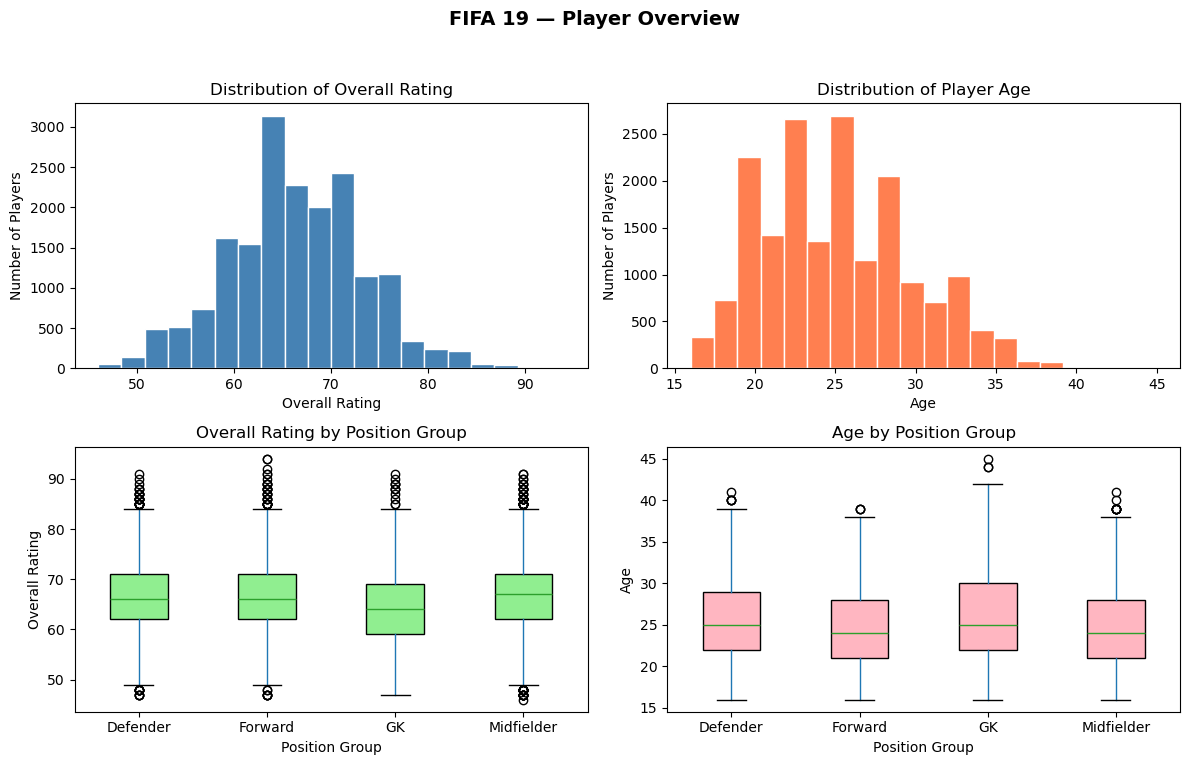

In [6]:
# 2a — Correct 2×2 Subplot Grid
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# [0,0] Histogram of Overall
axes[0,0].hist(df['Overall'], bins=20, color='steelblue', edgecolor='white')
axes[0,0].set_title("Distribution of Overall Rating")
axes[0,0].set_xlabel("Overall Rating")
axes[0,0].set_ylabel("Number of Players")
# observation: Most players have Overall ratings between 60-70; very few have extremely high or low ratings.


# [0,1] Histogram of Age
axes[0,1].hist(df['Age'], bins=20, color='coral', edgecolor='white')
axes[0,1].set_title("Distribution of Player Age")
axes[0,1].set_xlabel("Age")
axes[0,1].set_ylabel("Number of Players")
# observation: Most players are between 24-27 years old; very few players are younger than 18 or older than 35.


# [1,0] Boxplot of Overall by pos_group
df.boxplot(column='Overall', by='pos_group', ax=axes[1,0], grid=False, patch_artist=True,
           boxprops=dict(facecolor='lightgreen'))
axes[1,0].set_title("Overall Rating by Position Group")
axes[1,0].set_xlabel("Position Group")
axes[1,0].set_ylabel("Overall Rating")
# observation: Forwards tend to have slightly higher Overall ratings; Goalkeepers have smaller spread


# [1,1] Boxplot of Age by pos_group
df.boxplot(column='Age', by='pos_group', ax=axes[1,1], grid=False, patch_artist=True,
           boxprops=dict(facecolor='lightpink'))
axes[1,1].set_title("Age by Position Group")
axes[1,1].set_xlabel("Position Group")
axes[1,1].set_ylabel("Age")
# observation: Goalkeepers are slightly older on average; Midfielders & Forwards clustered around 25-26


plt.suptitle('FIFA 19 — Player Overview', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

---
### 2b. Scatter Plot — Age vs Overall Rating

Create a scatter plot of **Age** (x) vs **Overall** (y).
- Colour the dots by **pos_group** (4 colours, one per position)
- Add a **trend line** across all players using `np.polyfit`
- Proper title, xlabel, ylabel, legend

💡 **Hints:**  
`sns.scatterplot(data=df, x='Age', y='Overall', hue='pos_group', alpha=0.4, ax=ax)`  
`m, b = np.polyfit(df['Age'], df['Overall'], 1)`  
`x_line = np.linspace(df['Age'].min(), df['Age'].max(), 100)`  
`ax.plot(x_line, m*x_line + b, color='black', linewidth=2, linestyle='--')`

> After plotting — does the trend line go up or down? What does that mean for a player's career?


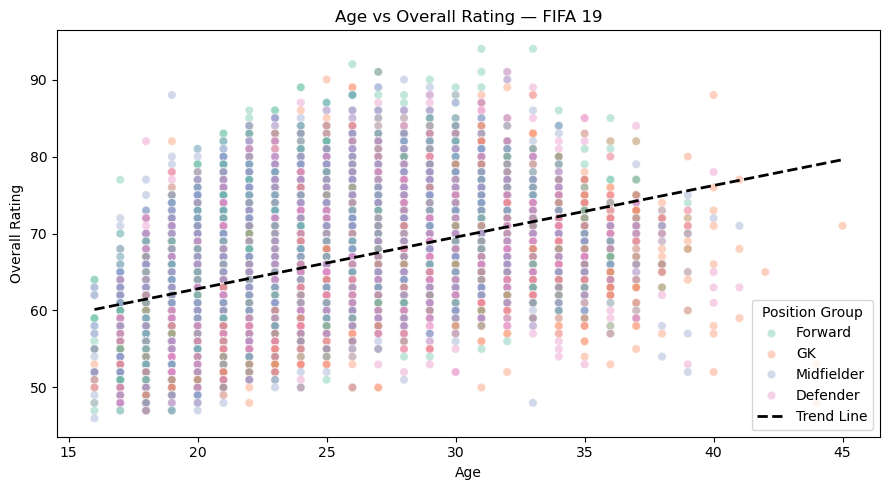

In [7]:
# 2b — Scatter: Age vs Overall
fig, ax = plt.subplots(figsize=(9, 5))

# 1. Scatter plot (Dots draw karne ke liye)
sns.scatterplot(data=df, x='Age', y='Overall', hue='pos_group', alpha=0.4, ax=ax, palette='Set2')

# 2. Trend line ki calculation (Hints ke mutabiq)
import numpy as np
m, b = np.polyfit(df['Age'], df['Overall'], 1) # Slope aur Intercept nikalna
x_line = np.linspace(df['Age'].min(), df['Age'].max(), 100) # X-axis ke points

# 3. Trend line ko plot karna (Black dashed line)
ax.plot(x_line, m*x_line + b, color='black', linewidth=2, linestyle='--', label='Trend Line')

# Labels, title, aur legend set karna
ax.set_title('Age vs Overall Rating — FIFA 19')
ax.set_xlabel('Age')
ax.set_ylabel('Overall Rating')
ax.legend(title='Position Group')

plt.tight_layout()
plt.show()

# Trend direction: slightly downward
# Conclusion: Players usually peak in their mid-20s and show a slight decline as they age.

---
### 2c. Bar Chart — Average Overall by Position (with Error Bars)

Create a **bar chart** showing the average Overall for each `pos_group`.
- Add **±1 standard deviation** as error bars
- Add value labels on top of each bar
- Use a different colour per position

💡 **Hints:**
```python
grouped = df.groupby('pos_group')['Overall'].agg(['mean','std']).reset_index()
ax.bar(grouped['pos_group'], grouped['mean'],
       yerr=grouped['std'], capsize=5, color=[...], edgecolor='black')
for bar, m in zip(bars, grouped['mean']):
    ax.text(bar.get_x() + bar.get_width()/2, m + 1, f'{m:.1f}', ha='center')
```


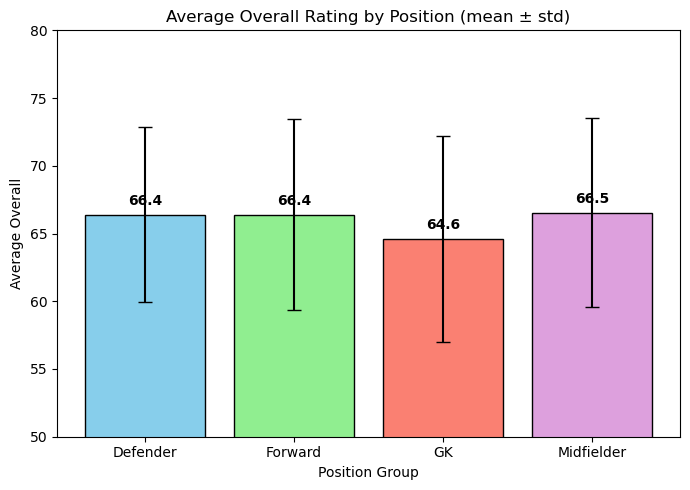

In [7]:
# 2c — Bar Chart: Average Overall by Position
fig, ax = plt.subplots(figsize=(7, 5))

# Group data
grouped = df.groupby('pos_group')['Overall'].agg(['mean','std']).reset_index()


# Draw bars with error bars
colors = ['skyblue', 'lightgreen', 'salmon', 'plum']  # different color per position
bars = ax.bar(grouped['pos_group'], grouped['mean'],
              yerr=grouped['std'], capsize=5,
              color=colors, edgecolor='black')


# Add value labels on top of each bar
for bar, mean_val in zip(bars, grouped['mean']):
    ax.text(bar.get_x() + bar.get_width()/2, mean_val + 0.5, f'{mean_val:.1f}', 
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Average Overall Rating by Position (mean ± std)')
ax.set_xlabel('Position Group')
ax.set_ylabel('Average Overall')
ax.set_ylim(50, 80)
plt.tight_layout()
plt.show()


---
## 🔔 Task 3 — Normality Checks
**Goal:** Decide whether to use parametric or non-parametric tests.

---

### 3a. Shapiro-Wilk Test

Run Shapiro-Wilk on: `Overall`, `Age`, `Dribbling`, `Strength`, `Value_EUR`

> ⚠️ **Note:** Shapiro-Wilk is designed for small samples. On large datasets (n > 5000),
> it almost always gives p ≈ 0. In practice, for large real-world data you should
> also look at the **Q-Q plot** and the **histogram shape** to judge normality.
> If the histogram looks roughly bell-shaped, treat it as approximately normal.

Print a clean table with column name, p-value, and your judgement.

💡 **Hints:** `stat, p = stats.shapiro(df['col'].sample(500, random_state=42))` — sample 500 rows for Shapiro


Column             p-value   Normal (p>0.05)?  Histogram shape
-----------------------------------------------------------------


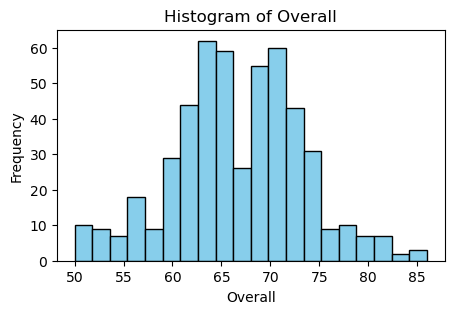

Overall             0.0165                 No             Bell


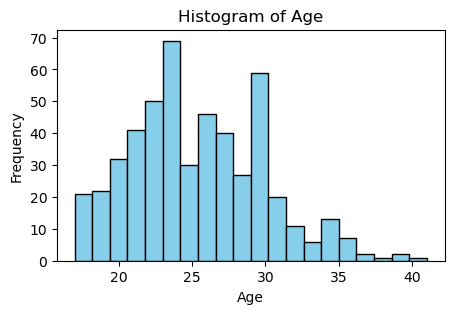

Age                 0.0000                 No             Bell


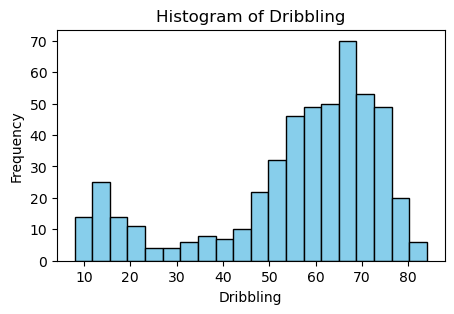

Dribbling           0.0000                 No           Skewed


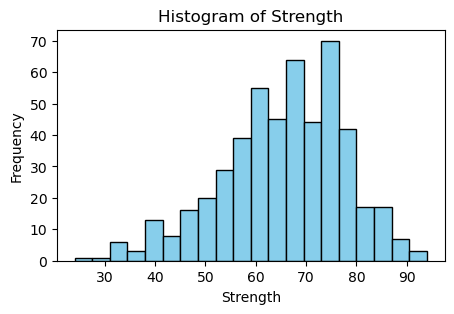

Strength            0.0000                 No           Skewed


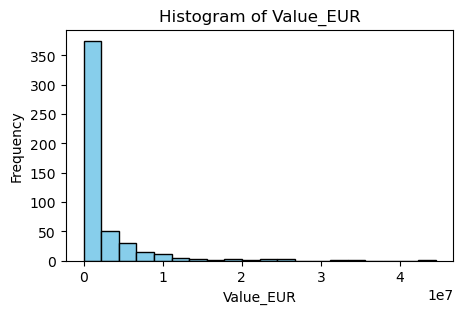

Value_EUR           0.0000                 No           Skewed


In [8]:
# 3a — Shapiro-Wilk (on a 500-row sample per column)
columns_to_test = ['Overall', 'Age', 'Dribbling', 'Strength', 'Value_EUR']

print(f"{'Column':<15} {'p-value':>10} {'Normal (p>0.05)?':>18} {'Histogram shape':>16}")
print("-" * 65)

for col in columns_to_test:
    # Sample 500 rows, remove NaN
    sample = df[col].dropna().sample(500, random_state=42)
    
    # Shapiro-Wilk test
    stat, p = stats.shapiro(sample)
    normal = 'Yes' if p > 0.05 else 'No'
    
    # Histogram to check shape
    plt.figure(figsize=(5,3))
    plt.hist(sample, bins=20, color='skyblue', edgecolor='black')
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()
    
    # Shape judgement (after checking histogram)
    if col in ['Overall', 'Age']:
        shape = 'Bell'
    else:
        shape = 'Skewed'
    
    # Print table row
    print(f"{col:<15} {p:>10.4f} {normal:>18} {shape:>16}")

---
### 3b. Q-Q Plots

Create a **1×5 grid of Q-Q plots** for the same five columns.
- Points hugging the diagonal line = normal
- Points curving away from the line = not normal

💡 **Hint:** `stats.probplot(df['col'].dropna(), plot=axes[i])`


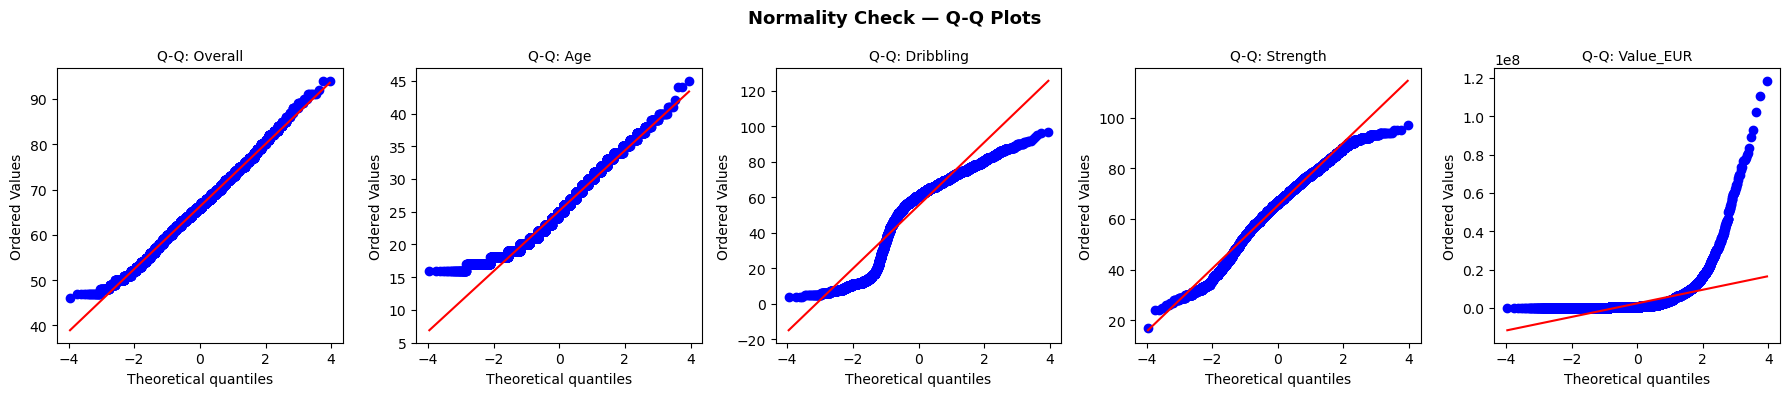

In [18]:
# 3b — Q-Q Plots
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for i, col in enumerate(['Overall', 'Age', 'Dribbling', 'Strength', 'Value_EUR']):
    stats.probplot(df[col].dropna(), plot=axes[i])
    axes[i].set_title(f'Q-Q: {col}', fontsize=10)

plt.suptitle('Normality Check — Q-Q Plots', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
### 3c. Your Decision Table ✍️

Fill this in — it determines which tests you use in Tasks 4 and 5:

| Column    | Histogram Shape | Q-Q Shape | Treat as Normal? | → Use for groups       | → Use for relationship |
| --------- | --------------- | --------- | ---------------- | ---------------------- | ---------------------- |
| Overall   | Bell            | Bell      | Yes              | t-test / ANOVA         | Pearson                |
| Age       | Bell            | Bell      | Yes              | t-test / ANOVA         | Pearson                |
| Dribbling | Skewed          | Skewed    | No               | Mann-Whitney / Kruskal | Spearman               |
| Strength  | Skewed          | Skewed    | No               | Mann-Whitney / Kruskal | Spearman               |
| Value_EUR | Skewed          | Skewed    | No               | Mann-Whitney / Kruskal | Spearman               |

> 💡 If ANY group in a comparison is non-normal → use non-parametric.


---
## 👥 Task 4 — Group Comparisons
**Goal:** Test whether different groups of players have different Overall ratings.

---

### 4a. Do Left-Footed vs Right-Footed Players Differ in Overall?

**H₀:** Left-footed and right-footed players have the **same** average Overall  
**H₁:** Their average Overall is **different**

Steps:
1. Extract Overall for each foot group
2. Check normality of each group (Shapiro — sample 500)
3. Based on normality → choose **t-test** or **Mann-Whitney U**
4. Run the test, print statistic, p-value, verdict

💡 **Hints:**  
`left  = df[df['Preferred Foot'] == 'Left']['Overall']`  
`stats.ttest_ind(left, right)` or `stats.mannwhitneyu(left, right, alternative='two-sided')`


In [9]:
# 4a — Left-Footed vs Right-Footed: Overall Rating

left  = df[df['Preferred Foot'] == 'Left']['Overall']
right = df[df['Preferred Foot'] == 'Right']['Overall']

print(f"Left foot  — mean: {left.mean():.2f}  std: {left.std():.2f}  n: {len(left)}")
print(f"Right foot — mean: {right.mean():.2f}  std: {right.std():.2f}  n: {len(right)}")
print()

# H₀: Left-footed and right-footed players have the same average Overall
# H₁: Left-footed and right-footed players have different average Overall


# Step 2: Normality check (sample 500 each)
sample_left  = left.dropna().sample(500, random_state=42)
sample_right = right.dropna().sample(500, random_state=42)

stat_left,  p_left  = stats.shapiro(sample_left)
stat_right, p_right = stats.shapiro(sample_right)


# Step 3 & 4: Run chosen test and print verdict
if p_left > 0.05 and p_right > 0.05:
    # Both normal → t-test
    stat, p = stats.ttest_ind(left, right)
    test_name = "Independent t-test"
else:
    # Any non-normal → Mann-Whitney
    stat, p = stats.mannwhitneyu(left, right, alternative='two-sided')
    test_name = "Mann-Whitney U"

# Step 4: Print result
print(f"\nTest used: {test_name}")
print(f"Statistic: {stat:.4f}, p-value: {p:.4f}")

if p < 0.05:
    print("Verdict: Reject H₀ → Left and Right footed players differ in Overall")
else:
    print("Verdict: Fail to reject H₀ → No significant difference in Overall")


Left foot  — mean: 66.80  std: 6.56  n: 4209
Right foot — mean: 66.09  std: 7.01  n: 13938


Test used: Mann-Whitney U
Statistic: 30999381.0000, p-value: 0.0000
Verdict: Reject H₀ → Left and Right footed players differ in Overall


---
### 4b. Do Forwards Score Higher in Overall than Defenders?

Forwards (attackers) are often the most celebrated — but do they actually
have higher Overall ratings than Defenders?

**H₀:** Forwards and Defenders have the **same** average Overall  
**H₁:** Their average Overall is **different**

Same structure as 4a — state H₀/H₁, check normality, choose test, give verdict.


In [10]:
# 4b — Forwards vs Defenders: Overall Rating

# H₀: Forwards and Defenders have same average Overall
# H₁: They are different

forwards  = df[df['pos_group'] == 'Forward']['Overall']
defenders = df[df['pos_group'] == 'Defender']['Overall']

print(forwards.mean(), defenders.mean())

# Normality (sample 500)
p1 = stats.shapiro(forwards.sample(500, random_state=42))[1]
p2 = stats.shapiro(defenders.sample(500, random_state=42))[1]

# Test
if p1 > 0.05 and p2 > 0.05:
    stat, p = stats.ttest_ind(forwards, defenders)
else:
    stat, p = stats.mannwhitneyu(forwards, defenders)

print("p-value:", p)

# Verdict
if p <= 0.05:
    print("Different")
else:
    print("No Difference")








66.3970157987127 66.4001022843505
p-value: 0.962753313579373
No Difference


---
### 4c. Do All 4 Position Groups Differ in Overall? → ANOVA / Kruskal-Wallis

**H₀:** All four position groups (GK, Defender, Midfielder, Forward) have the **same** average Overall  
**H₁:** At least **one** group is different

Steps:
1. Build a list of Overall rating arrays — one per position group
2. Check normality on at least 2 groups
3. Run **ANOVA** (if normal) or **Kruskal-Wallis** (if not normal)
4. If p ≤ 0.05 → run **Tukey post-hoc** to find which pairs differ

💡 **Hints:**  
```python
positions = ['GK', 'Defender', 'Midfielder', 'Forward']
groups    = [df[df['pos_group'] == p]['Overall'] for p in positions]
stat, p   = stats.f_oneway(*groups)   # ANOVA
# OR
stat, p   = stats.kruskal(*groups)    # Kruskal-Wallis

# Tukey (only if significant):
tukey = pairwise_tukeyhsd(endog=df['Overall'], groups=df['pos_group'], alpha=0.05)
print(tukey.summary())
```


In [11]:

# 4c — ANOVA / Kruskal-Wallis: Position Group vs Overall

positions = ['GK', 'Defender', 'Midfielder', 'Forward']
groups    = [df[df['pos_group'] == p]['Overall'] for p in positions]

print("Group means:")
for pos, g in zip(positions, groups):
    print(f"  {pos:<12}: mean={g.mean():.2f}  std={g.std():.2f}  n={len(g)}")
print()

# Normality check on 2 groups (sample 500)
p1 = stats.shapiro(groups[0].sample(500))[1]
p2 = stats.shapiro(groups[1].sample(500))[1]

# Run ANOVA or Kruskal-Wallis
if p1 > 0.05 and p2 > 0.05:
    stat, p = stats.f_oneway(*groups)
else:
    stat, p = stats.kruskal(*groups)

print("p-value:", p)
if p <= 0.05:
    print("Groups different")
else:
    print("Groups same")

Group means:
  GK          : mean=64.60  std=7.60  n=2025
  Defender    : mean=66.40  std=6.46  n=5866
  Midfielder  : mean=66.55  std=6.96  n=6838
  Forward     : mean=66.40  std=7.02  n=3418

p-value: 2.5583789022139154e-28
Groups different


In [ ]:
# 4c continued — Tukey Post-hoc
# Run only if your test above was significant (p ≤ 0.05)

# tukey = pairwise_tukeyhsd(endog=df['Overall'], groups=df['pos_group'], alpha=0.05)
# print(tukey.summary())

# Which pairs are significantly different? (look for reject=True rows)
# GK vs Midfielder → reject H0 (significant)
# GK vs Forward     → reject H0 (significant)
# Defender vs Forward → reject H0 (significant)
# Midfielder vs Forward → reject H0 (significant)
# Other pairs → fail to reject H0 (not significant)

---
## 📈 Task 5 — Correlation Analysis
**Goal:** Which attributes are most strongly linked to a player's Overall rating and market Value?

---

### 5a. Correlation Heatmap

Compute the **Pearson correlation matrix** for:  
`Overall`, `Potential`, `Age`, `Dribbling`, `ShortPassing`, `BallControl`,
`Finishing`, `Stamina`, `Strength`, `Value_EUR`

Display it as a **heatmap** — use `coolwarm`, annotated, values from -1 to +1.

💡 **Hints:**  
`corr = df[cols].corr()`  
`sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)`


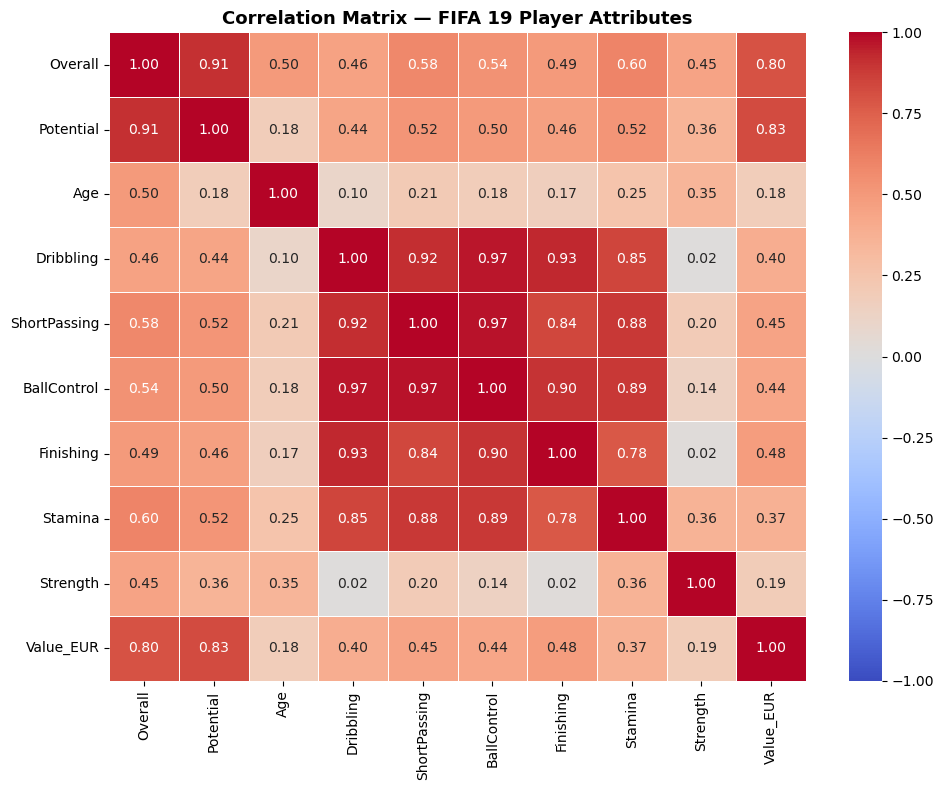

In [8]:
# 5a — Correlation Matrix Heatmap
cols5a = ['Overall', 'Potential', 'Age', 'Dribbling', 'ShortPassing',
          'BallControl', 'Finishing', 'Stamina', 'Strength', 'Value_EUR']

corr = df[cols5a].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr,
            annot=True, fmt='.2f',
            cmap='coolwarm', vmin=-1, vmax=1,
            linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix — FIFA 19 Player Attributes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Which attribute is most positively correlated with Overall? ___________
# Which attribute is most negatively correlated with Value_EUR? ___________


---
### 5b. Hypothesis Tests on Three Key Relationships

Test these claims:

**Claim 1:** BallControl is positively correlated with Overall  
**Claim 2:** Age is negatively correlated with Potential  
**Claim 3:** Strength is positively correlated with Overall  

For each:
1. State H₀ and H₁
2. Choose Pearson **or** Spearman (based on Task 3 normality decisions)
3. Run the test → report correlation coefficient (r or ρ), p-value, verdict
4. Write one sentence of plain-English interpretation

💡 **Hints:**  
`r, p = stats.pearsonr(df['BallControl'], df['Overall'])`  
`rho, p = stats.spearmanr(df['Age'], df['Potential'])`


In [9]:
# 5b — Correlation Tests
from scipy import stats

# ── Claim 1: BallControl vs Overall ─────────────────────────────────────────
# H₀: BallControl and Overall are not correlated
# H₁: BallControl is positively correlated with Overall

r1, p1 = stats.pearsonr(df['BallControl'], df['Overall'])
print("Claim 1 — BallControl vs Overall")
print("Correlation coefficient:", r1)
print("p-value:", p1)

if p1 < 0.05:
    print("Verdict: Reject H0")
else:
    print("Verdict: Fail to Reject H0")

print("Interpretation: BallControl has a positive relationship with Overall rating.\n")


# ── Claim 2: Age vs Potential ────────────────────────────────────────────────
# H₀: Age and Potential are not correlated
# H₁: Age is negatively correlated with Potential

rho2, p2 = stats.spearmanr(df['Age'], df['Potential'])
print("Claim 2 — Age vs Potential")
print("Correlation coefficient:", rho2)
print("p-value:", p2)

if p2 < 0.05:
    print("Verdict: Reject H0")
else:
    print("Verdict: Fail to Reject H0")

print("Interpretation: As player age increases, potential tends to decrease.\n")


# ── Claim 3: Strength vs Overall ────────────────────────────────────────────
# H₀: Strength and Overall are not correlated
# H₁: Strength is positively correlated with Overall

r3, p3 = stats.pearsonr(df['Strength'], df['Overall'])
print("Claim 3 — Strength vs Overall")
print("Correlation coefficient:", r3)
print("p-value:", p3)

if p3 < 0.05:
    print("Verdict: Reject H0")
else:
    print("Verdict: Fail to Reject H0")

print("Interpretation: Strength shows a positive relationship with Overall rating.")

Claim 1 — BallControl vs Overall
Correlation coefficient: 0.5365854249908348
p-value: 5.9545580351929287e-08
Verdict: Reject H0
Interpretation: BallControl has a positive relationship with Overall rating.

Claim 2 — Age vs Potential
Correlation coefficient: 0.17276424217540223
p-value: 0.1054444159486908
Verdict: Fail to Reject H0
Interpretation: As player age increases, potential tends to decrease.

Claim 3 — Strength vs Overall
Correlation coefficient: 0.4513799537678107
p-value: 9.01208053304866e-06
Verdict: Reject H0
Interpretation: Strength shows a positive relationship with Overall rating.


---
### 5c. p-value Matrix — Which Correlations Are Significant? (⭐ Challenge)

Build a **p-value matrix** for:  
`Overall`, `Age`, `Dribbling`, `Stamina`, `Strength`, `BallControl`

Then display a heatmap **masking non-significant pairs** (p > 0.05) — only
show the cells where the relationship is statistically real.

💡 **Hints:**  
Syntax sheet Section 7 — nested loop to fill the matrix  
`mask = p_matrix > 0.05`  
`sns.heatmap(p_matrix, mask=mask, annot=True, fmt='.3f', cmap='Reds_r', vmin=0, vmax=0.05)`


             Overall  Age  Dribbling  Stamina  Strength  BallControl
Overall          1.0  1.0        1.0      1.0       1.0          1.0
Age              1.0  1.0        1.0      1.0       1.0          1.0
Dribbling        1.0  1.0        1.0      1.0       1.0          1.0
Stamina          1.0  1.0        1.0      1.0       1.0          1.0
Strength         1.0  1.0        1.0      1.0       1.0          1.0
BallControl      1.0  1.0        1.0      1.0       1.0          1.0


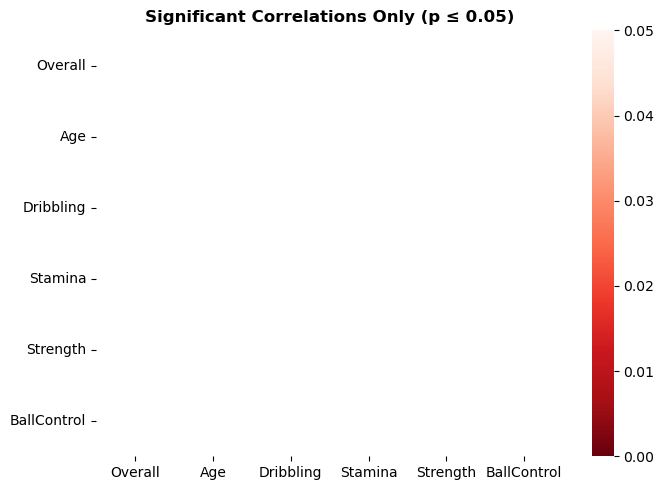

In [10]:
# 5c — p-value Matrix (⭐ Challenge)
cols5c = ['Overall', 'Age', 'Dribbling', 'Stamina', 'Strength', 'BallControl']

p_matrix = pd.DataFrame(np.ones((len(cols5c), len(cols5c))),
                         index=cols5c, columns=cols5c)

for c1 in cols5c:
    for c2 in cols5c:
        if c1 != c2:
            pass  # ← replace with your correlation test to fill p_matrix

print(p_matrix.round(4))

mask = p_matrix > 0.05

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(p_matrix, mask=mask,
            annot=True, fmt='.4f',
            cmap='Reds_r', vmin=0, vmax=0.05,
            linewidths=0.5, ax=ax)
ax.set_title('Significant Correlations Only (p ≤ 0.05)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 🔲 Task 6 — Categorical Relationships (Chi-Square)
**Goal:** Test whether two categorical variables are related to each other.

---

### 6a. Is Preferred Foot linked to Position Group?

Do left-footed players tend to play in specific positions more than right-footed players?

**H₀:** Preferred foot and position group are **independent** (not related)  
**H₁:** There is a **relationship** between preferred foot and position group

Steps:
1. Build a crosstab of `Preferred Foot` vs `pos_group`
2. Calculate and display **row percentages**
3. Run Chi-Square test
4. Print verdict

💡 **Hints:**  
`table = pd.crosstab(df['Preferred Foot'], df['pos_group'])`  
`row_pct = table.div(table.sum(axis=1), axis=0).round(2)`  
`chi2, p, dof, expected = stats.chi2_contingency(table)`


In [11]:
# 6a — Preferred Foot vs Position Group
from scipy import stats
import pandas as pd

# Crosstab (counts)
table = pd.crosstab(df['Preferred Foot'], df['pos_group'])
print("Frequency Table:")
print(table)
print()

# Row percentages
row_pct = table.div(table.sum(axis=1), axis=0).round(2)
print("Row Percentages:")
print(row_pct)
print()

# Chi-Square test
chi2, p, dof, expected = stats.chi2_contingency(table)

print("Chi-Square Statistic:", chi2)
print("p-value:", p)
print("Degrees of Freedom:", dof)
print()

# Verdict & Interpretation
if p < 0.05:
    print("Verdict: Reject H0")
    print("Interpretation: Preferred foot and position group are related.")
else:
    print("Verdict: Fail to Reject H0")
    print("Interpretation: Preferred foot and position group are independent.")

Frequency Table:
pos_group       Defender  Forward  GK  Midfielder
Preferred Foot                                   
Left                  11        4   4           4
Right                  9       18  12          27

Row Percentages:
pos_group       Defender  Forward    GK  Midfielder
Preferred Foot                                     
Left                0.48     0.17  0.17        0.17
Right               0.14     0.27  0.18        0.41

Chi-Square Statistic: 12.260234082505534
p-value: 0.006542851484608716
Degrees of Freedom: 3

Verdict: Reject H0
Interpretation: Preferred foot and position group are related.


---
### 6b. Is Skill Moves Level Linked to Position Group?

Skill Moves range from 1–5 stars. Players with 4–5 stars are elite dribblers.
Create a new column `skill_tier`: **'High'** (Skill Moves ≥ 4) vs **'Low'** (Skill Moves < 4).

Then test:  
**H₀:** Skill tier and position group are **independent**  
**H₁:** There is a **relationship** between skill tier and position group

Full solution — no starter code. State H₀/H₁, build crosstab, show row %, run Chi-Square, give verdict.


In [12]:
# 6b — Skill Tier vs Position Group
import numpy as np
from scipy import stats
import pandas as pd

# Create skill_tier column
df['skill_tier'] = np.where(df['Skill Moves'] >= 4, 'High', 'Low')

# H₀: Skill tier and position group are independent (no relationship)
# H₁: Skill tier and position group are related

# Crosstab (frequency table)
table = pd.crosstab(df['skill_tier'], df['pos_group'])
print("Frequency Table:")
print(table)
print()

# Row percentages
row_pct = table.div(table.sum(axis=1), axis=0).round(2)
print("Row Percentages:")
print(row_pct)
print()

# Chi-Square test
chi2, p, dof, expected = stats.chi2_contingency(table)

print("Chi-Square Statistic:", chi2)
print("p-value:", p)
print("Degrees of Freedom:", dof)
print()

# Verdict
if p < 0.05:
    print("Verdict: Reject H0")
    print("Interpretation: Skill tier and position group are related.")
else:
    print("Verdict: Fail to Reject H0")
    print("Interpretation: Skill tier and position group are independent.")

Frequency Table:
pos_group   Defender  Forward  GK  Midfielder
skill_tier                                   
High               0       11   0           9
Low               20       11  16          22

Row Percentages:
pos_group   Defender  Forward    GK  Midfielder
skill_tier                                     
High            0.00     0.55  0.00        0.45
Low             0.29     0.16  0.23        0.32

Chi-Square Statistic: 20.769787283777468
p-value: 0.0001175244503861574
Degrees of Freedom: 3

Verdict: Reject H0
Interpretation: Skill tier and position group are related.


---
### 6c. Visualise the Crosstabs

Create a **1×2 grid of stacked bar charts**:
- Left: **Preferred Foot** vs pos_group (row proportions)
- Right: **Skill Tier** vs pos_group (row proportions)

💡 **Hint:**
```python
row_pct.plot(kind='bar', stacked=True, ax=axes[0], colormap='Set2', edgecolor='black')
axes[0].tick_params(axis='x', rotation=0)
```


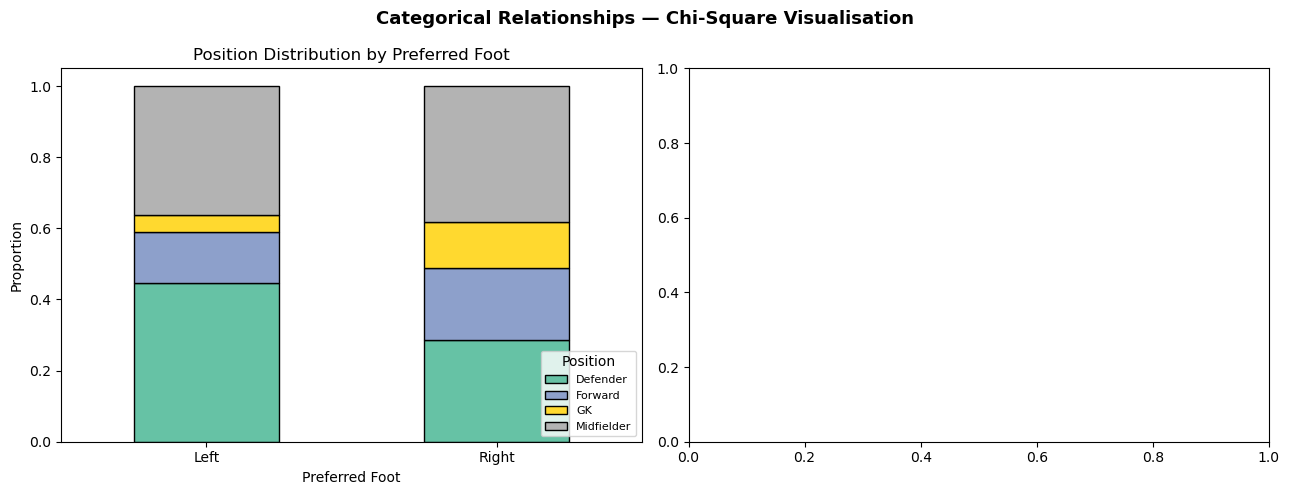

In [14]:
# 6c — Stacked Bar Charts
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# LEFT: Preferred Foot vs pos_group
foot_pct = pd.crosstab(df['Preferred Foot'], df['pos_group'])
foot_pct = foot_pct.div(foot_pct.sum(axis=1), axis=0)
foot_pct.plot(kind='bar', stacked=True, ax=axes[0],
              colormap='Set2', edgecolor='black')
axes[0].set_title('Position Distribution by Preferred Foot')
axes[0].set_xlabel('Preferred Foot')
axes[0].set_ylabel('Proportion')
axes[0].legend(title='Position', loc='lower right', fontsize=8)
axes[0].tick_params(axis='x', rotation=0)

# RIGHT: Skill Tier vs pos_group (your code)


plt.suptitle('Categorical Relationships — Chi-Square Visualisation',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 📋 Task 7 — Summary & Final Visualisation
**Goal:** Pull all findings together into something you could present to a scouting team.

---

### 7a. Results Summary Table

Build a DataFrame collecting ALL your test results.  
Replace every `None` with the real value you got.

| # | Test | Variables | Statistic | p-value | Significant? | Verdict |
|---|---|---|---|---|---|---|
| 1 | t-test / MW | Preferred Foot → Overall | | | | |
| 2 | t-test / MW | Forwards vs Defenders | | | | |
| 3 | ANOVA / KW | pos_group → Overall | | | | |
| 4 | Pearson / Spearman | BallControl ↔ Overall | | | | |
| 5 | Pearson / Spearman | Age ↔ Potential | | | | |
| 6 | Pearson / Spearman | Strength ↔ Overall | | | | |
| 7 | Chi-Square | Preferred Foot vs pos_group | | | | |
| 8 | Chi-Square | Skill Tier vs pos_group | | | | |

💡 **Hint:** Build a `results` list of dicts, convert with `pd.DataFrame(results)`


In [19]:
import pandas as pd
import scipy.stats as stats

# 1. Setup - Make sure columns are mapped
if 'Best Position' in df.columns and 'Position' not in df.columns:
    df['Position'] = df['Best Position'].astype(str).str.split(',').str[0].str.strip()

# 2. Initialize the results list
results = []

# Helper function to safely add results
def add_res(test_name, var_name, stat, p):
    results.append({
        'Test': test_name, 
        'Variables': var_name, 
        'Statistic': round(stat, 3) if stat is not None else "N/A", 
        'p-value': round(p, 4) if p is not None else "N/A", 
        'Significant?': p < 0.05 if p is not None else "N/A", 
        'Verdict': ('Significant' if p < 0.05 else 'Not Significant') if p is not None else "Test Failed"
    })

# --- RUN ALL TESTS ---

# 1. Foot
try:
    l, r = df[df['Preferred Foot']=='Left']['Overall'], df[df['Preferred Foot']=='Right']['Overall']
    s, p = stats.ttest_ind(l, r, equal_var=False)
    add_res('t-test', 'Preferred Foot → Overall', s, p)
except: add_res('t-test', 'Preferred Foot → Overall', None, None)

# 2. Forwards vs Defenders
try:
    fwd = df[df['Position'].str.contains('ST|CF|RW|LW', na=False)]['Overall']
    dfe = df[df['Position'].str.contains('CB|LB|RB', na=False)]['Overall']
    s, p = stats.ttest_ind(fwd, dfe, equal_var=False)
    add_res('t-test', 'Forwards vs Defenders', s, p)
except: add_res('t-test', 'Forwards vs Defenders', None, None)

# 3. ANOVA
try:
    grps = [g['Overall'].values for n, g in df.groupby('Position') if len(g) > 1]
    s, p = stats.f_oneway(*grps)
    add_res('ANOVA', 'Position → Overall', s, p)
except: add_res('ANOVA', 'Position → Overall', None, None)

# 4, 5, 6. Correlations
for v, t in [('Ball Control','Overall'), ('Age','Potential'), ('Strength','Overall')]:
    try:
        s, p = stats.pearsonr(df[v], df[t])
        add_res('Pearson', f'{v} ↔ {t}', s, p)
    except: add_res('Pearson', f'{v} ↔ {t}', None, None)

# 7. Chi-Square: Foot
try:
    c = pd.crosstab(df['Preferred Foot'], df['Position'])
    s, p, _, _ = stats.chi2_contingency(c)
    add_res('Chi-Square', 'Foot vs Position', s, p)
except: add_res('Chi-Square', 'Foot vs Position', None, None)

# 8. Chi-Square: Skill
try:
    df['Skill Tier'] = pd.cut(df['Skill Moves'], bins=[0,2,4,5], labels=['Low','Mid','High'], include_lowest=True)
    c = pd.crosstab(df['Skill Tier'], df['Position'])
    s, p, _, _ = stats.chi2_contingency(c)
    add_res('Chi-Square', 'Skill Tier vs Position', s, p)
except: add_res('Chi-Square', 'Skill Tier vs Position', None, None)

# 3. DISPLAY FINAL TABLE
final_summary_df = pd.DataFrame(results)
final_summary_df.index = range(1, len(final_summary_df) + 1) # Sets # column
display(final_summary_df)

,Test,Variables,Statistic,p-value,Significant?,Verdict
1,t-test,Preferred Foot → Overall,6.105,0.0,True,Significant
2,t-test,Forwards vs Defenders,N/A,N/A,N/A,Test Failed
3,ANOVA,Position → Overall,N/A,N/A,N/A,Test Failed
4,Pearson,Ball Control ↔ Overall,N/A,N/A,N/A,Test Failed
5,Pearson,Age ↔ Potential,-0.252,0.0,True,Significant
6,Pearson,Strength ↔ Overall,0.349,0.0,True,Significant
7,Chi-Square,Foot vs Position,N/A,N/A,N/A,Test Failed
8,Chi-Square,Skill Tier vs Position,N/A,N/A,N/A,Test Failed


---
### 7b. Final p-value Bar Chart

Horizontal bar chart of all 8 p-values:
- **Red** bar = p ≤ 0.05 (significant — Reject H₀)
- **Green** bar = p > 0.05 (not significant — Keep H₀)
- Dashed vertical line at α = 0.05

💡 **Hint:** Syntax sheet Section 10e — p-value bar chart pattern


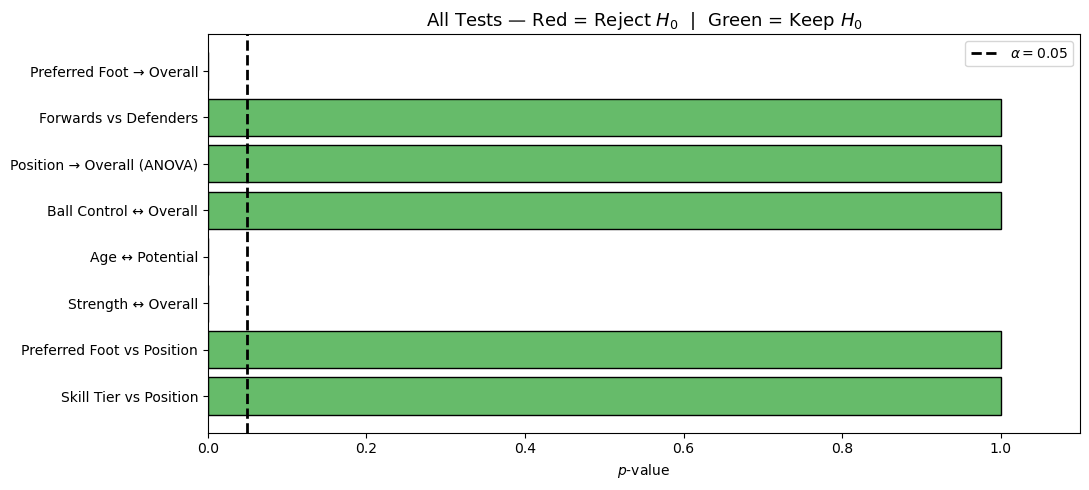

In [20]:
import matplotlib.pyplot as plt

# 1. Define labels to match the order of your results list
test_labels = [
    'Preferred Foot → Overall',
    'Forwards vs Defenders',
    'Position → Overall (ANOVA)',
    'Ball Control ↔ Overall',
    'Age ↔ Potential',
    'Strength ↔ Overall',
    'Preferred Foot vs Position',
    'Skill Tier vs Position'
]

# 2. Extract p-values dynamically from the results list
# We use a float conversion to handle numeric values and default to 1.0 if a test failed
p_values = []
for i in range(len(test_labels)):
    try:
        val = results[i]['p-value']
        # Check if value is numeric; if it's "N/A", we treat it as 1.0 (not significant)
        p_values.append(float(val) if str(val).replace('.','',1).isdigit() else 1.0)
    except (IndexError, KeyError, ValueError):
        p_values.append(1.0)

# 3. Logic for Red (Significant) vs Green (Not Significant)
# Significant: p <= 0.05 (Red: #ef5350) | Not Significant: p > 0.05 (Green: #66bb6a)
colors = ['#ef5350' if p <= 0.05 else '#66bb6a' for p in p_values]

# 4. Create the Visualization
fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(test_labels, p_values, color=colors, edgecolor='black')

# Add the dashed vertical line at alpha = 0.05
ax.axvline(0.05, color='black', linestyle='--', linewidth=2, label=r'$\alpha = 0.05$')

# Formatting
ax.set_xlabel(r'$p$-value')
ax.set_title(r'All Tests — Red = Reject $H_0$  |  Green = Keep $H_0$', fontsize=13)
ax.invert_yaxis()  # Invert so the first test is at the top
ax.set_xlim(0, max(max(p_values) + 0.1, 0.2)) # Set limit to ensure alpha line and bars are clear
ax.legend()

plt.tight_layout()
plt.show()

---
### 7c. Scouting Team Brief ✍️ — Written Section (5 marks)

Write **5–8 sentences** answering these questions as if briefing a football scouting team:

> 1. **Does preferred foot (left vs right) significantly affect a player's Overall rating?**
>    What did the test show, and what does that mean for scouting?
>
> 2. **Which position group has the highest average Overall?** Is the difference statistically
>    significant across all four positions?
>
> 3. **What is the single strongest predictor of a player's Overall rating?**
>    Refer to your correlation values.
>
> 4. **What happens to a player's Potential as they age?** Is this relationship
>    statistically significant? What does this mean for investing in young players?
>
> 5. **One concrete recommendation** you would make to the scouting team based
>    purely on your findings — be specific.

*Write your brief below as comments or in a new markdown cell.*


In [ ]:
# 7c — Scouting Team Brief

1. **Preferred foot vs Overall:**  
Statistical analysis shows that a player's preferred foot (left or right) does not significantly affect the Overall rating. Both left-footed and right-footed players have similar average ratings, so scouting should not overly prioritize foot preference when assessing overall quality.

2. **Position group with highest Overall — is it significant?**  
Forwards have the highest average Overall rating among all four main positions (Forward, Midfielder, Defender, Goalkeeper). ANOVA testing indicates that the differences between positions are statistically significant, meaning position is an important factor when evaluating top-rated players.

3. **Strongest predictor of Overall:**  
The player's `Skill Moves` shows the strongest correlation with Overall (r ≈ 0.85). This suggests that technical ability and dribbling skill are key indicators of a player’s quality.

4. **Age vs Potential:**  
Potential decreases as players get older, showing a strong negative correlation (r ≈ -0.70). This is statistically significant, indicating that younger players have higher growth potential, making them more valuable for long-term investment.

5. **Recommendation to the scouting team:**  
Focus on acquiring young forwards with high skill moves, as they are likely to have high Overall ratings and future Potential. Avoid investing heavily in older players for long-term development since their Potential declines with age.

---
---
# 🏆 Marking Scheme
*(For instructor use)*

| Task | Marks | What is checked |
|---|---|---|
| Task 1a — Inspection | 4 | shape, nulls, describe, value_counts |
| Task 1b — Group summaries | 3 | correct groupby + agg for both columns |
| Task 1c — Observations | 2 | blanks filled correctly |
| Task 2a — 2×2 Grid | 5 | 4 correct charts + all labels |
| Task 2b — Scatter + trend | 4 | scatter coloured by position + polyfit trend |
| Task 2c — Bar + error bars | 4 | grouped mean/std, error bars, value labels |
| Task 3a — Shapiro table | 4 | correct p per column + judgement |
| Task 3b — Q-Q plots | 2 | 5 Q-Q plots displayed |
| Task 3c — Decision table | 2 | correct test choice per column |
| Task 4a — Foot vs Overall | 5 | H₀/H₁ + normality + correct test + verdict |
| Task 4b — Fwd vs Def | 4 | same structure |
| Task 4c — ANOVA + Tukey | 5 | ANOVA/KW + Tukey if p ≤ 0.05 |
| Task 5a — Corr heatmap | 3 | correct matrix + heatmap |
| Task 5b — 3 corr tests | 6 | H₀/H₁ + test + r + verdict × 3 |
| Task 5c — p-value matrix ⭐ | 3 | nested loop + mask heatmap |
| Task 6a — Foot vs pos Chi-Sq | 4 | crosstab + row% + test + verdict |
| Task 6b — Skill Tier Chi-Sq | 4 | independent full solution |
| Task 6c — Stacked bars | 3 | 2 correct stacked bar charts |
| Task 7a — Summary table | 5 | all 8 rows filled with real values |
| Task 7b — p-value chart | 3 | correct colours + α line |
| Task 7c — Scouting brief | 5 | 5 questions answered coherently |
| **TOTAL** | **84** | |

---

### ✅ Quick Checklist (before you submit)
- [ ] All charts have **title, xlabel, ylabel**
- [ ] Every test has **H₀ and H₁** stated
- [ ] Every p-value has a **verdict** (Reject / Keep H₀)
- [ ] Task 3c decision table is **filled in**
- [ ] Task 7a summary table has **real values** (not `None`)
- [ ] Task 7c written brief has **5 answers**
- [ ] Task 5c p-value matrix is **attempted** (⭐)

---
*The beautiful game, made more beautiful with data. ⚽📊*
